Linear Algebra II

Part A — the curriculum activities

Task 01

Visualise the four transformations

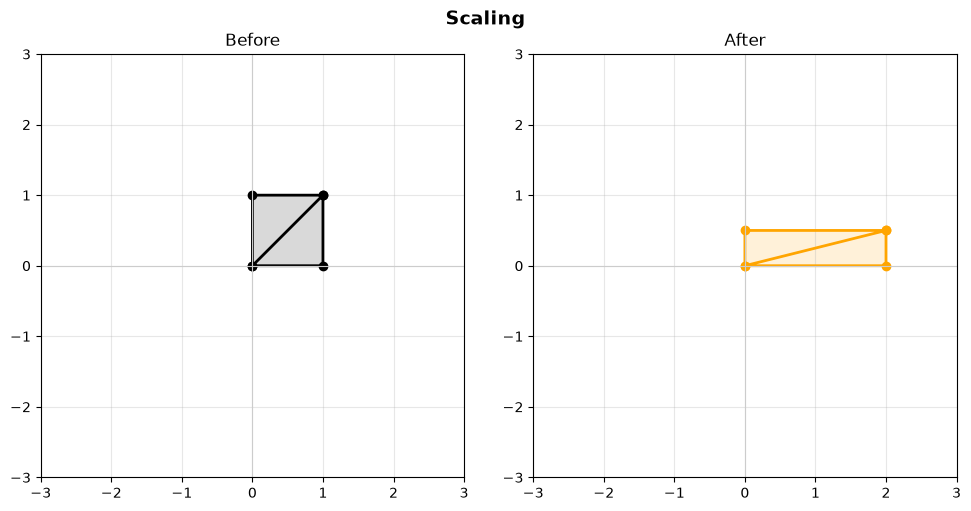

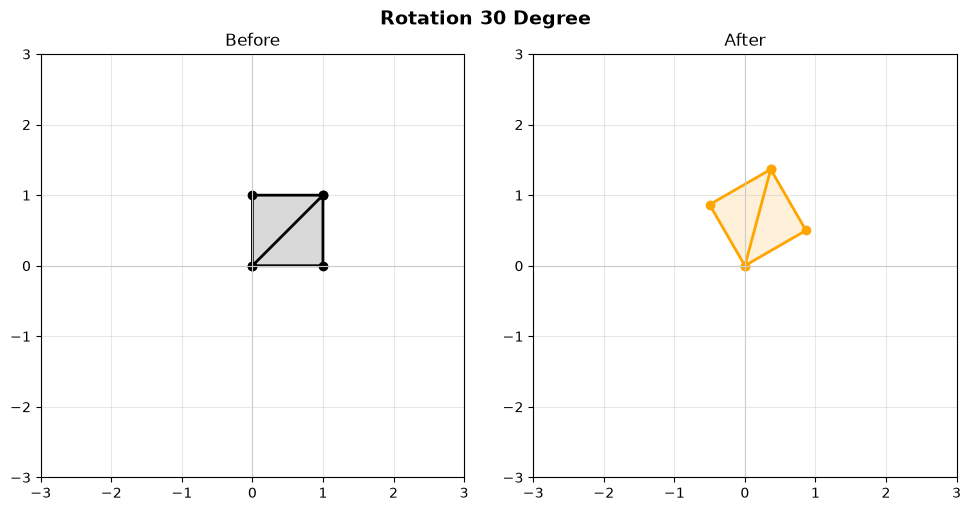

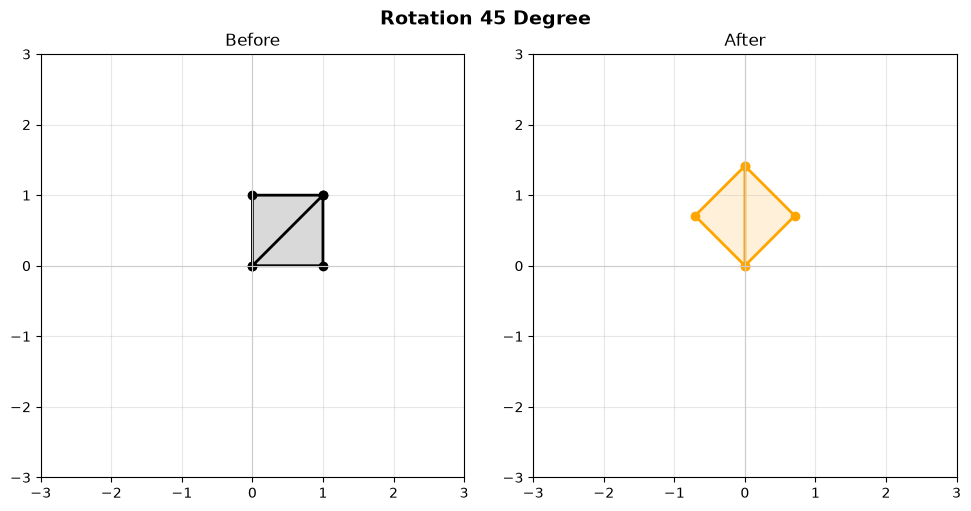

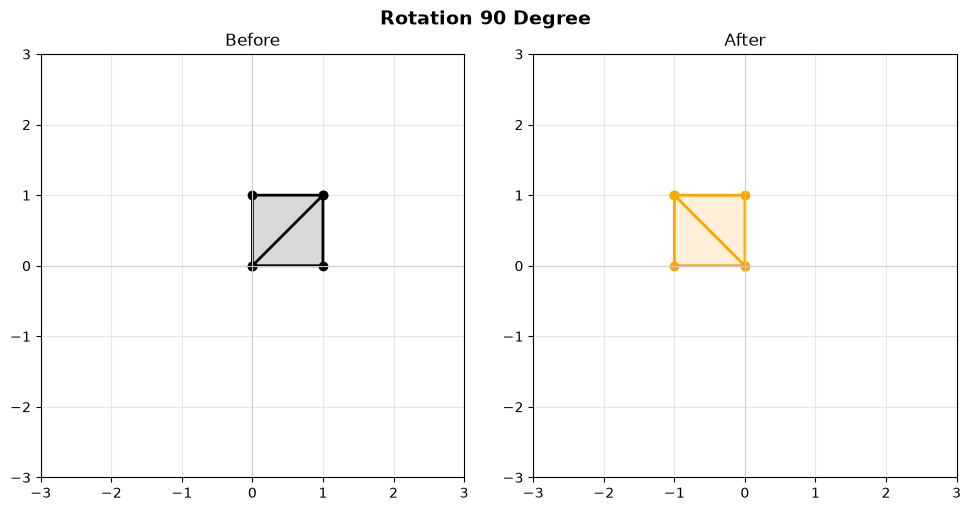

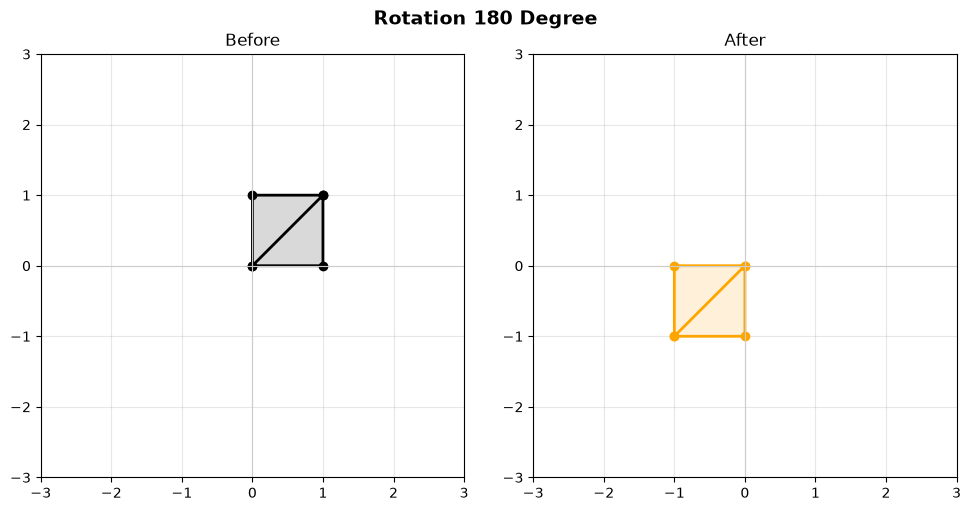

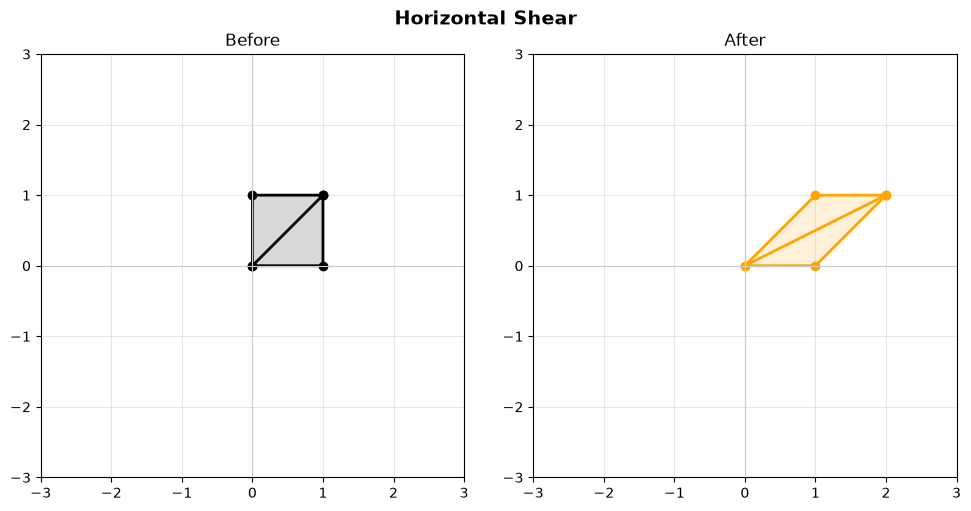

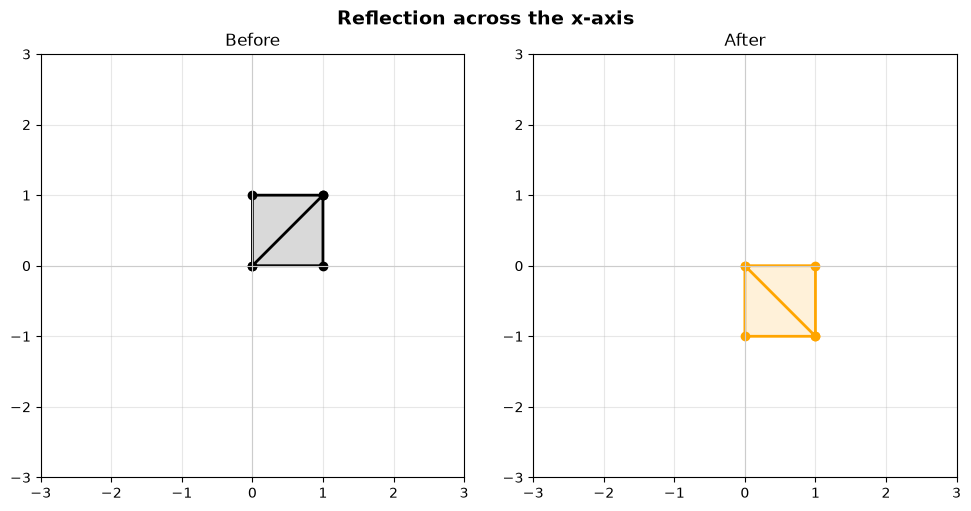

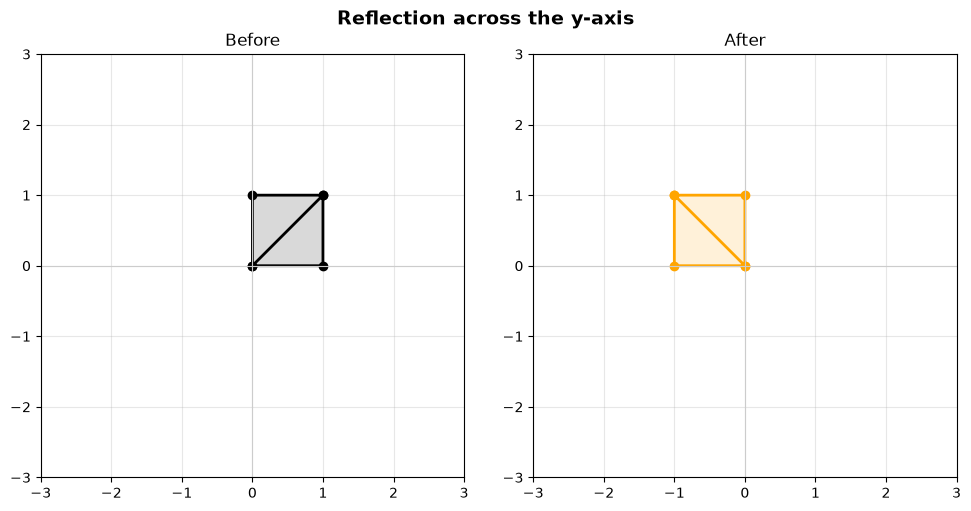

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# House Shape
shape = np.array([[0, 1, 1, 0, 0, 1],
                  [0, 0, 1, 1, 0, 1]], dtype=float)

# Rotation Matrix
def rotation(degrees):
    t = np.radians(degrees)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

# Function to plot Before and After
def show_transformation(matrix, title=""):
    transformed = matrix @ shape
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, pts, ttl, col in [(axes[0], shape, "Before", "black"),
                              (axes[1], transformed, "After", "orange")]:
        ax.plot(pts[0], pts[1], "-o", color=col, linewidth=2)
        ax.fill(pts[0], pts[1], color=col, alpha=0.15)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.axhline(0, color="#ccc", lw=0.8)
        ax.axvline(0, color="#ccc", lw=0.8)
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Scaling
scale = np.array([[2, 0],
                  [0, 0.5]])

show_transformation(scale, "Scaling")
# x by 2 and y is half of height means y squish.

# Rotation
show_transformation(rotation(30), "Rotation 30 Degree")

show_transformation(rotation(45), "Rotation 45 Degree")

show_transformation(rotation(90), "Rotation 90 Degree")

show_transformation(rotation(180), "Rotation 180 Degree")
# Shape rotate to the desire angles but the size still remains means size is unchanged.

# Shear
shear = np.array([[1, 1],
                  [0, 1]])

show_transformation(shear, "Horizontal Shear")
# Points are shifted to upper side.

# Reflection
ref = np.array([[1, 0],
                [0, -1]])

show_transformation(ref, "Reflection across the x-axis")
# The shape flips vertically across the x-axis while the x-coordinates remain unchanged.


ref = np.array([[-1, 0],
                [0, 1]])

show_transformation(ref, "Reflection across the y-axis")
# The Shape flips horizontally acrtoss the y-axis while the y-coordinates remain unchanged.

Task 02

Compute determinants and check invertibility

Determinants

Scales       Determinant1.00
Rotation     Determinant1.00
Shear        Determinant1.00
Reflection   Determinant-1.00

Singular Matrix Determinant =  0.0


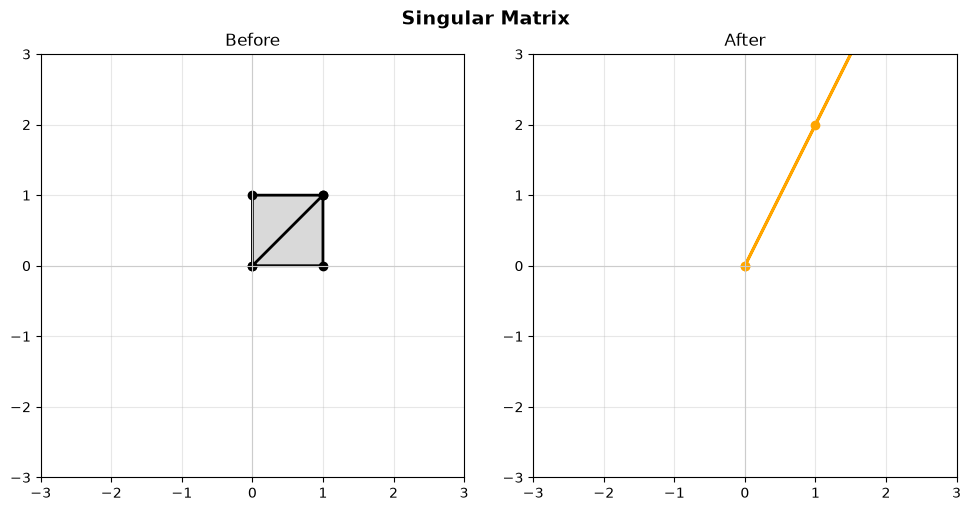

0.0

Invertibility

Scales : True
Rotation : True
Shear : True
Reflection : True
Singular :  False


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# House Shape
shape = np.array([[0, 1, 1, 0, 0, 1],
                  [0, 0, 1, 1, 0, 1]], dtype=float)

# Rotation Matrix
def rotation(degrees):
    t = np.radians(degrees)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

# Show Transformation
def show_transformation(matrix, title=""):
    transformed = matrix @ shape
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, pts, ttl, col in [(axes[0], shape, "Before", "black"),
                              (axes[1], transformed, "After", "orange")]:
        ax.plot(pts[0], pts[1], "-o", color=col, linewidth=2)
        ax.fill(pts[0], pts[1], color=col, alpha=0.15)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.axhline(0, color="#ccc", lw=0.8)
        ax.axvline(0, color="#ccc", lw=0.8)
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Matrices
scale = np.array([[2, 0],
                  [0, 0.5]])
# Area is same but shape width double and height half.

rot = rotation(30)
# In rotation only shape rotates and there is no change in size and area.

shear = np.array([[1, 1],
                  [0, 1]])
# square get the shape of parallelogram but the area still same(unchanged).

ref = np.array([[1, 0],
                [0, -1]])
# Negative determinant means formed only a mirror image. Therefore, the area is same,
# orientation gets reverse.

# Determinants
matrices = {
    "Scales" : scale,
    "Rotation" : rot,
    "Shear" : shear,
    "Reflection" : ref
}

print("Determinants\n")

for name, matrix in matrices.items():
    det = np.linalg.det(matrix)
    print(f"{name:12s} Determinant{det:.2f}")


# Singular Matrix
sing = np.array([[1, 2],
                 [2, 4]])

print("\nSingular Matrix Determinant = ", np.linalg.det(sing))
show_transformation(sing, "Singular Matrix")

# Try Invert
try:
    inv = np.linalg.det(sing)
    print(inv)
except np.linalg.LinAlgError as e :
    print("\nInverse Error : ", e)

# Invertible Function
def is_invertible(matrix):
    return not np.isclose(np.linalg.det(matrix), 0)

print("\nInvertibility\n")
for name, matrix in matrices.items():
    print(name, ":", is_invertible(matrix))

print("Singular : ", is_invertible(sing))

# If the determinant is zero, the transformation squashes the shape into 
# a lower dimension (like a line or a point).
# Since information is lost, the original shape cannot be recovered,
# so the matrix has no inverse.

Task 03

Verify associativity: (AB)C = A(BC)

Left((A @ B) @ C)
[[1.41421356 1.06066017]
 [1.41421356 1.76776695]]

Right(A @ (B @ C))
[[1.41421356 1.06066017]
 [1.41421356 1.76776695]]

Associative? True

A @ B
[[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]

B @ A
[[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]

Commutative? False


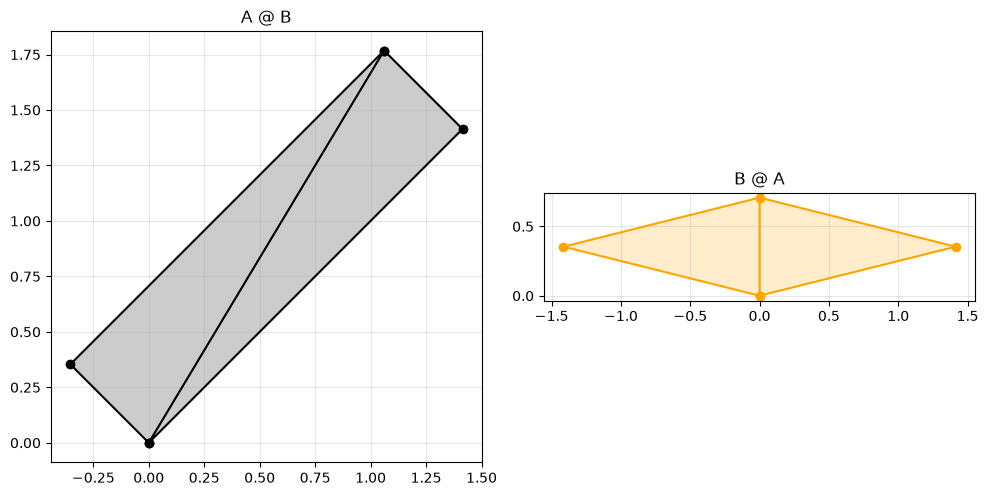

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# House Shape
shape = np.array([[0, 1, 1, 0, 0, 1],
                  [0, 0, 1, 1, 0, 1]], dtype=float)

# Matrix A Rotation 45 Degree
t = np.radians(45)

A = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

# Matrix B Scaling
B = np.array([
    [2, 0],
    [0, 0.5]
])

# Matrix C Shear
C = np.array([
    [1, 1],
    [0, 1]
])

# Associative Property
left = (A @ B) @ C
right = A @ (B @ C)

print("Left((A @ B) @ C)")
print(left)

print("\nRight(A @ (B @ C))")
print(right)

print("\nAssociative?", np.allclose(left, right))

# Commutative Property
AB = A @ B
BA = B @ A

print("\nA @ B")
print(AB)

print("\nB @ A")
print(BA)

print("\nCommutative?", np.allclose(AB, BA))

# Apply Transformations
shape_AB = AB @ shape
shape_BA = BA @ shape

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# A @ B
ax[0].plot(shape_AB[0], shape_AB[1], "-o", color="black")
ax[0].fill(shape_AB[0], shape_AB[1], color="black", alpha=0.2)
ax[0].set_title("A @ B")
ax[0].set_aspect("equal")
ax[0].grid(alpha=0.3)

# B @ A
ax[1].plot(shape_BA[0], shape_BA[1], "-o", color="orange")
ax[1].fill(shape_BA[0], shape_BA[1], color="orange", alpha=0.2)
ax[1].set_title("B @ A")
ax[1].set_aspect("equal")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Part B — compose and apply

Task 04

Compose a sequence of transformations

Are both results equal?
True

Determinants
det_S =  2.25
det_R =  1.0
det_Sh =  1.0
det_combined =  2.25

Products of determinants =  2.25

Verification : 
True


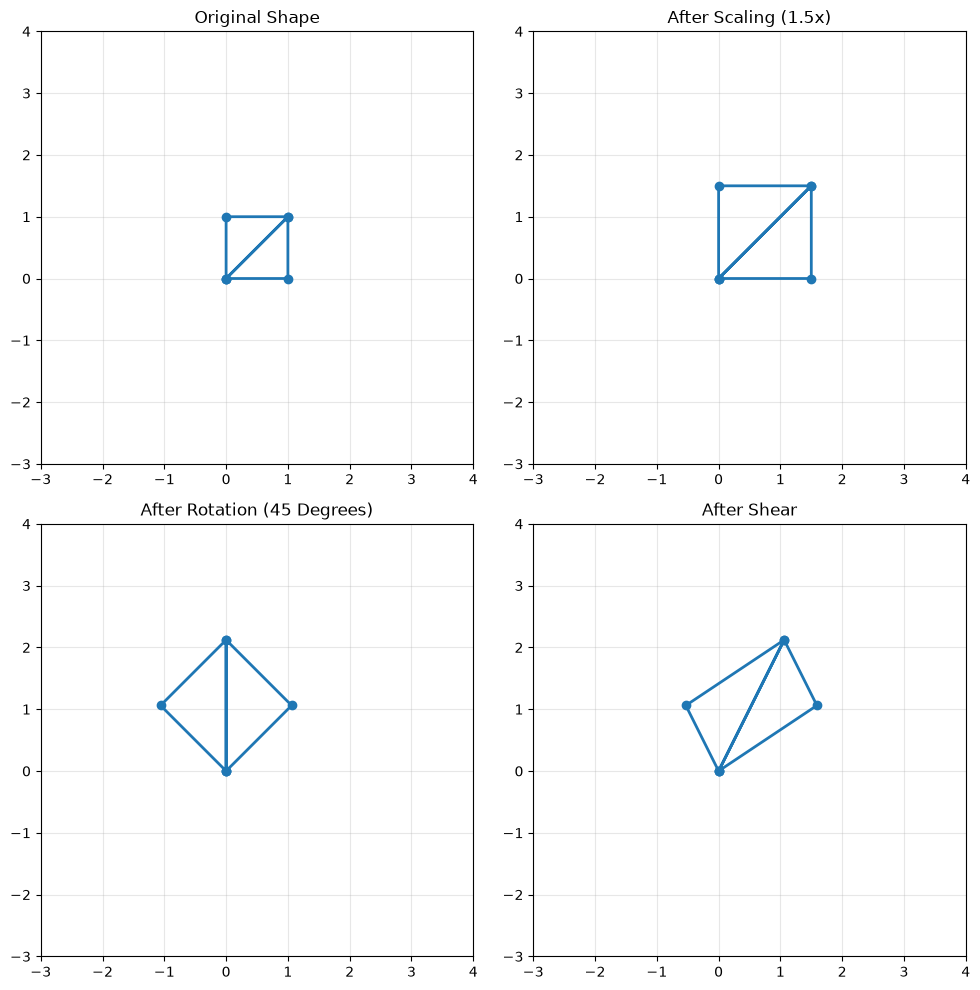


Final Shape (Step by Step)
[[ 0.          1.59099026  1.06066017 -0.53033009  0.          1.06066017]
 [ 0.          1.06066017  2.12132034  1.06066017  0.          2.12132034]]

Final Shape (Combined Matrix)
[[ 0.          1.59099026  1.06066017 -0.53033009  0.          1.06066017]
 [ 0.          1.06066017  2.12132034  1.06066017  0.          2.12132034]]


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Original Shape (House)
shape = np.array([[0, 1, 1, 0, 0, 1],
                  [0, 0, 1, 1, 0, 1]], dtype=float)

# Rotation Function
def rotation(angle):
    theta = np.radians(angle)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# Transformation Matrices
# scale by 1.5
S = np.array([
    [1.5, 0],
    [0, 1.5]
])

# Rotate by 45 Degree
R = rotation(45)

# Shear
Sh = np.array([
    [1, 0.5],
    [0, 1]
])

# Apply transformation one by one
scaled = S @ shape
rotated = R @ scaled
sheared = Sh @ rotated

# Combined Matrix
# First applied matrix goes on RIGHT
combined = Sh @ R @ S

combined_shape = combined @ shape

# Verify The Methods
print("Are both results equal?")
print(np.allclose(sheared, combined_shape))

# Determinants
det_S = np.linalg.det(S)
det_R = np.linalg.det(R)
det_Sh = np.linalg.det(Sh)
det_combined = np.linalg.det(combined)

print("\nDeterminants")
print("det_S = ", det_S)
print("det_R = ", det_R)
print("det_Sh = ", det_Sh)
print("det_combined = ", det_combined)

print("\nProducts of determinants = ", det_S * det_R * det_Sh)

print("\nVerification : ")
print(np.isclose(det_combined, det_S * det_R * det_Sh))

# Plot Function
def draw(ax, points, title):
    closed = np.hstack((points, points[:, [0]]))

    ax.plot(closed[0], closed[1], marker='o', linewidth=2)

    ax.set_title(title)
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.set_aspect("equal")

    ax.grid(alpha=0.3)


#Plot all stages (2x2)
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

draw(ax[0, 0], shape, "Original Shape")
draw(ax[0, 1], scaled, "After Scaling (1.5x)")
draw(ax[1, 0], rotated, "After Rotation (45 Degrees)")
draw(ax[1, 1], sheared, "After Shear")

plt.tight_layout()
plt.show()

# Compare final coordinates
print("\nFinal Shape (Step by Step)")
print(sheared)

print("\nFinal Shape (Combined Matrix)")
print(combined_shape)

Task 05

Special matrices and their properties

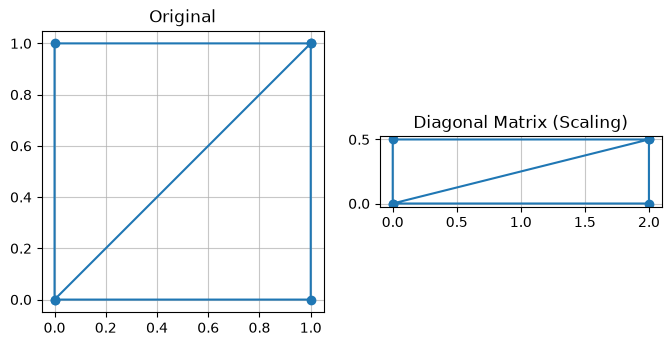


Symmetric Matrix
[[2. 1.]
 [1. 3.]]

A == A.T?
True

Rotation Matrix (Orthogonal) : 
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]

Q.T @ Q = 
[[1.00000000e+00 7.43708407e-18]
 [7.43708407e-18 1.00000000e+00]]

Orthogonal
True

Original Length =  5.0
Length After Rotation =  5.0
Length Preserved?
True

Angle before rotation =  45.00000000000001
Angle after rotation =  45.0
After Preserved?
True

Why orthogonal matrices are useful in ML : 
Orthogonal matrices preserves lengths and angles, so they rotate data without distorting its geometry


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Helper Function (Rotation Matrix)
def rotation(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# Shape (House)
shape = np.array([[0, 1, 1, 0, 0, 1],
                  [0, 0, 1, 1, 0, 1]], dtype=float)

# Draw Function
def draw(ax, points, title):
    ax.plot(points[0], points[1], marker='o')
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.7)

# 1. Diagonal Matrix
D = np.array([
    [2, 0],
    [0, 0.5]
])

scaled = D @ shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

draw(ax[0], shape, "Original")
draw(ax[1], scaled, "Diagonal Matrix (Scaling)")

plt.show()

# 2. Symmetric Matrix
sym = np.array([
    [2., 1.],
    [1., 3.]
])

print("\nSymmetric Matrix")
print(sym)

print("\nA == A.T?")
print(np.allclose(sym, sym.T))

# 3. Orthogonal Matrix
Q = rotation(30)

print("\nRotation Matrix (Orthogonal) : ")
print(Q)

print("\nQ.T @ Q = ")
print(Q.T @ Q)

print("\nOrthogonal")
print(np.allclose(Q.T @ Q, np.eye(2)))

# 4. Length Preservation
v = np.array([3.0, 4.0])

original_length = np.linalg.norm(v)
new_length = np.linalg.norm(Q @ v)

print("\nOriginal Length = ", original_length)
print("Length After Rotation = ", new_length)

print("Length Preserved?")
print(np.isclose(original_length, new_length))

# 5. Angle Preservation
a = np.array([2., 1.])
b = np.array([1., 3.])

def angle(u, w):
    cos_theta = np.dot(u, w) / (np.linalg.norm(u) * np.linalg.norm(w))
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.degrees(np.arccos(cos_theta))

before = angle(a, b)
after = angle(Q @ a, Q @ b)

print("\nAngle before rotation = ", before)
print("Angle after rotation = ", after)

print("After Preserved?")
print(np.isclose(before, after))

# 6. ML Explaination
print("\nWhy orthogonal matrices are useful in ML : ")
print("Orthogonal matrices preserves lengths and angles, so they rotate data without distorting its geometry")

Part C — put it together

Task 06

An interactive transformation explorer

Matrix:
 [[1. 0.]
 [0. 1.]]

Columns (where basis vectors land)
e1 ->  [1. 0.]
e2 ->  [0. 1.]

Determenant =  1.0


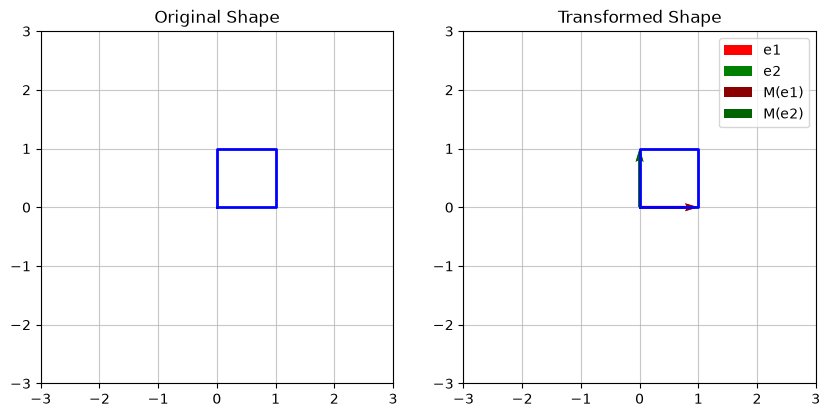

Matrix:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Columns (where basis vectors land)
e1 ->  [0.70710678 0.70710678]
e2 ->  [-0.70710678  0.70710678]

Determenant =  1.0


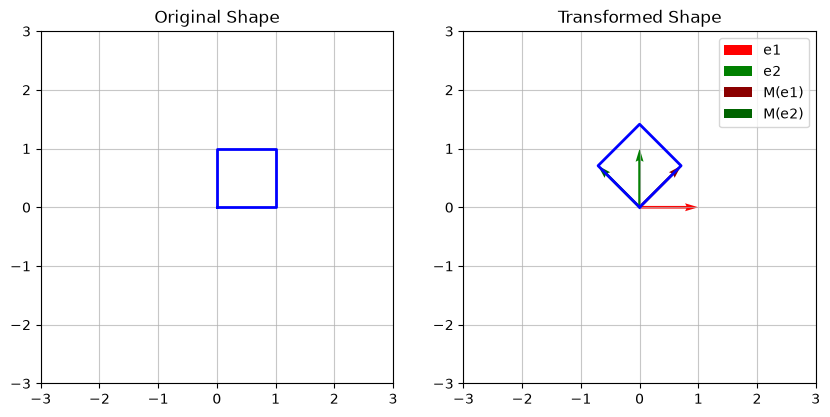

Matrix:
 [[2. 0.]
 [0. 2.]]

Columns (where basis vectors land)
e1 ->  [2. 0.]
e2 ->  [0. 2.]

Determenant =  4.0


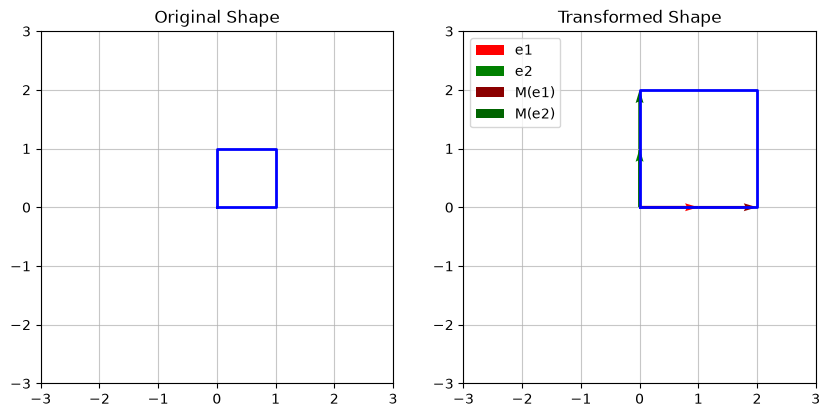

Matrix:
 [[-1.  0.]
 [ 0.  1.]]

Columns (where basis vectors land)
e1 ->  [-1.  0.]
e2 ->  [0. 1.]

Determenant =  -1.0


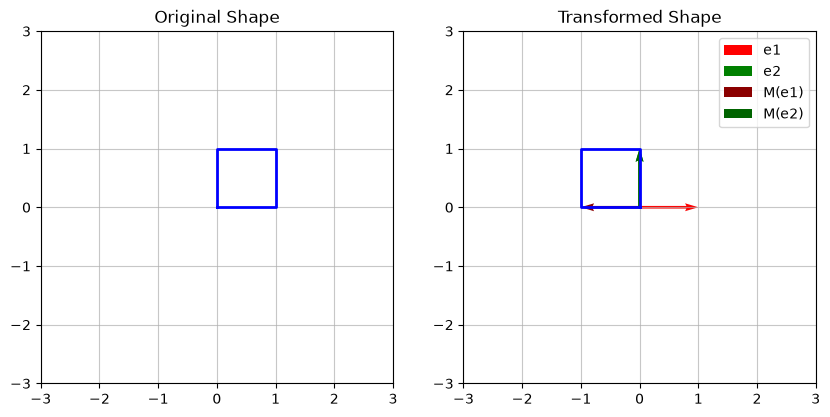

Matrix:
 [[-2.  0.]
 [ 0.  2.]]

Columns (where basis vectors land)
e1 ->  [-2.  0.]
e2 ->  [0. 2.]

Determenant =  -4.0


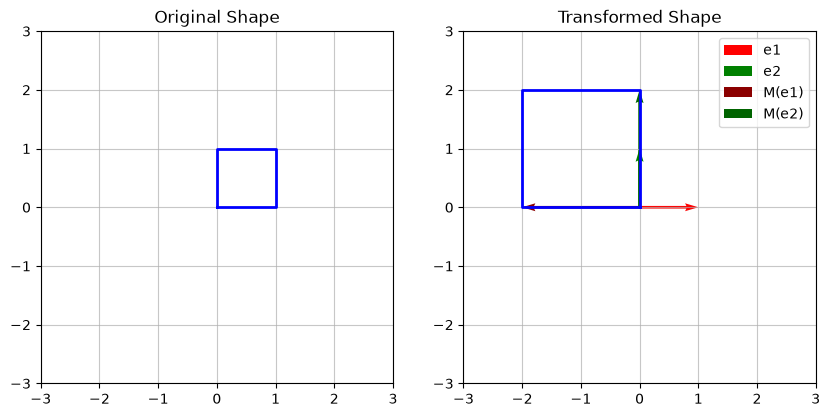

Matrix:
 [[1. 2.]
 [2. 4.]]

Columns (where basis vectors land)
e1 ->  [1. 2.]
e2 ->  [2. 4.]

Determenant =  0.0


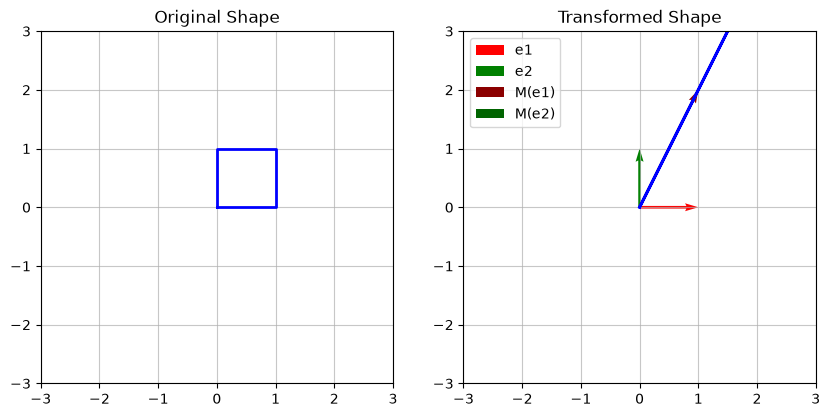

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Square Shape
shape = np.array([[0, 1, 1, 0, 0],
                  [0, 0, 1, 1, 0]])

# Draw Function
def draw(ax, points, title):
    ax.plot(points[0], points[1], 'b-', linewidth=2)
    ax.set_aspect("equal")
    ax.grid(alpha=0.7)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(title)

# Show Transformation
def show_transformation(M):
    transformed = M @ shape
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    draw(ax[0], shape, "Original Shape")
    draw(ax[1], transformed, "Transformed Shape")

    # Original basis vector
    ax[1].quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color="red", label='e1')
    ax[1].quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color="green", label='e2')

    # Transformed basis vector
    ax[1].quiver(0, 0, M[0,0], M[1,0], angles='xy', scale_units='xy', scale=1, color='darkred', label='M(e1)')
    ax[1].quiver(0, 0, M[0,1], M[1,1], angles='xy', scale_units='xy', scale=1, color='darkgreen', label='M(e2)')

    ax[1].legend()

    plt.show()


# Explore Function
def explore(a, b, c, d):
    M = np.array([
        [a, b],
        [c, d]
    ], dtype=float)

    print('=' * 40)
    print("Matrix:\n", M)
    print()

    print("Columns (where basis vectors land)")
    print("e1 -> ", M[:,0])
    print("e2 -> ", M[:,1])

    det = np.linalg.det(M)
    print("\nDetermenant = ", det)

    show_transformation(M)

explore(1, 0, 0, 1)

# Pure Rotation
theta = np.radians(45)
explore(np.cos(theta), -np.sin(theta),
        np.sin(theta),  np.cos(theta))

# Pure Scaling
explore(2, 0, 0, 2)

# Pure Reflection
explore(-1, 0, 0, 1)

# Negative Determinant but Normal Scaling
explore(-2, 0, 0, 2)

# Collapse Square to Line
explore(1, 2, 2, 4)

| Matrix                           | Transformation   | Determinant |
| -------------------------------- | ---------------- | ----------: |
| `[[1,0],[0,1]]`                  | Identity         |           1 |
| `[[2,0],[0,2]]`                  | Scaling (2×)     |           4 |
| `[[cos45,-sin45],[sin45,cos45]]` | Rotation 45°     |           1 |
| `[[-1,0],[0,1]]`                 | Reflection       |          -1 |
| `[[1,2],[2,4]]`                  | Collapse to line |           0 |
